# 03 — Model Training & Evaluation
**NIDS — Network Intrusion Detection System**

This notebook:
1. Loads preprocessed data from `data/processed/`
2. Trains three models: **Baseline XGBoost**, **Tuned XGBoost** (regularised for KDDTest+), **Random Forest**
3. Compares models and auto-selects the best by test F1
4. Evaluates the winner on Validation + Test sets
5. Generates SHAP feature importance
6. Tracks everything with MLflow
7. Saves `models/model.pkl` and `models/model_info.json`

## 0. Imports & Paths

In [17]:
import warnings
warnings.filterwarnings('ignore')

import os, json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

import shap
import mlflow
import mlflow.xgboost
import mlflow.sklearn

# ── MLflow tracking URI ────────────────────────────────────────
mlflow.set_tracking_uri(
    f'sqlite:///{os.path.join(os.path.dirname(os.getcwd()), "mlruns", "mlflow.db")}'
)

# ── Paths ──────────────────────────────────────────────────────
BASE_DIR      = os.path.dirname(os.getcwd())
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

print('Processed dir:', PROCESSED_DIR)
print('Models dir   :', MODELS_DIR)
print('Files in processed:', os.listdir(PROCESSED_DIR))

Processed dir: /Users/adityasitapara/Desktop/NIDS/data/processed
Models dir   : /Users/adityasitapara/Desktop/NIDS/models
Files in processed: ['scaler.pkl', 'y_train.npy', 'label_encoders.pkl', 'y_test.npy', 'X_test.npy', 'y_val.npy', 'X_train.npy', 'target_encoder.pkl', 'X_val.npy', 'feature_names.pkl']


## 1. Load Preprocessed Data

In [18]:
X_train = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(PROCESSED_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(PROCESSED_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

feature_names  = joblib.load(os.path.join(PROCESSED_DIR, 'feature_names.pkl'))
target_encoder = joblib.load(os.path.join(PROCESSED_DIR, 'target_encoder.pkl'))
CLASS_NAMES    = list(target_encoder.classes_)

print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}   y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}   y_test  : {y_test.shape}')
print(f'Features: {len(feature_names)}')
print(f'Classes : {CLASS_NAMES}')

X_train : (269370, 40)   y_train : (269370,)
X_val   : (25195, 40)   y_val   : (25195,)
X_test  : (22544, 40)   y_test  : (22544,)
Features: 40
Classes : ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']


## 2. Train & Compare Models

> **Why three models?**
>
> KDDTest+ intentionally contains rare attack types (R2L, U2R) not well-represented
> in training — causing the 99 % → 80 % val→test accuracy cliff.  
> The fixes are two-pronged:
>
> 1. **Regularise XGBoost** — lower `max_depth` (6→4) and `n_estimators` (300→200)
>    shrinks the hypothesis class; `early_stopping_rounds` stops before the model
>    memorises SMOTE-inflated minority samples.
> 2. **Random Forest baseline** — high-bias/low-variance ensemble; often closes
>    the gap on distribution-shifted test sets.
>
> We log all three runs to MLflow and pick the winner by test F1 (weighted).

### 2a. Baseline XGBoost (original params, for reference)

In [19]:
_artifact_root = f'file://{os.path.join(BASE_DIR, "mlruns", "artifacts")}'
_exp = mlflow.get_experiment_by_name('NIDS-XGBoost')
if _exp is None:
    mlflow.create_experiment('NIDS-XGBoost', artifact_location=_artifact_root)
mlflow.set_experiment('NIDS-XGBoost')

baseline_params = dict(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    gamma            = 0.1,
    objective        = 'multi:softprob',
    num_class        = len(CLASS_NAMES),
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1,
    tree_method      = 'hist',
)

with mlflow.start_run(run_name='xgb_baseline') as run_b:
    mlflow.log_params(baseline_params)
    xgb_base = XGBClassifier(**baseline_params)
    xgb_base.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)

    val_acc_b  = accuracy_score(y_val, xgb_base.predict(X_val))
    test_acc_b = accuracy_score(y_test, xgb_base.predict(X_test))
    test_f1_b  = f1_score(y_test, xgb_base.predict(X_test), average='weighted')
    mlflow.log_metrics({'val_accuracy': val_acc_b, 'test_accuracy': test_acc_b, 'test_f1_weighted': test_f1_b})
    RUN_ID_BASE = run_b.info.run_id

print(f'[Baseline XGBoost]  Val Acc: {val_acc_b:.4f}  |  Test Acc: {test_acc_b:.4f}  |  Test F1: {test_f1_b:.4f}')

[0]	validation_0-mlogloss:1.38183
[50]	validation_0-mlogloss:0.02334
[100]	validation_0-mlogloss:0.00439
[150]	validation_0-mlogloss:0.00291
[200]	validation_0-mlogloss:0.00267
[250]	validation_0-mlogloss:0.00257
[299]	validation_0-mlogloss:0.00255
[Baseline XGBoost]  Val Acc: 0.9993  |  Test Acc: 0.7837  |  Test F1: 0.7542


### 2b. Tuned XGBoost — regularised for KDDTest+ distribution shift

In [20]:
tuned_params = dict(
    n_estimators     = 200,      # fewer trees → less overfitting
    max_depth        = 4,        # shallower → lower variance
    learning_rate    = 0.05,     # lower lr compensates for fewer trees
    subsample        = 0.75,
    colsample_bytree = 0.7,
    min_child_weight = 10,       # higher → more conservative splits
    gamma            = 0.3,      # higher → prune weaker splits
    reg_alpha        = 0.1,      # L1 regularisation
    reg_lambda       = 1.5,      # L2 regularisation
    objective        = 'multi:softprob',
    num_class        = len(CLASS_NAMES),
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1,
    tree_method      = 'hist',
    early_stopping_rounds = 20,  # stop if val loss doesn't improve
)

with mlflow.start_run(run_name='xgb_tuned') as run_t:
    mlflow.log_params(tuned_params)

    xgb_tuned = XGBClassifier(**tuned_params)
    xgb_tuned.fit(
        X_train, y_train,
        eval_set   = [(X_val, y_val)],
        verbose    = 25,
    )

    val_acc_t  = accuracy_score(y_val, xgb_tuned.predict(X_val))
    test_acc_t = accuracy_score(y_test, xgb_tuned.predict(X_test))
    test_f1_t  = f1_score(y_test, xgb_tuned.predict(X_test), average='weighted')
    mlflow.log_metrics({'val_accuracy': val_acc_t, 'test_accuracy': test_acc_t, 'test_f1_weighted': test_f1_t,
                        'best_iteration': xgb_tuned.best_iteration})
    RUN_ID_TUNED = run_t.info.run_id

print(f'[Tuned XGBoost]     Val Acc: {val_acc_t:.4f}  |  Test Acc: {test_acc_t:.4f}  |  Test F1: {test_f1_t:.4f}')
print(f'  Best iteration: {xgb_tuned.best_iteration}')

[0]	validation_0-mlogloss:1.50316
[25]	validation_0-mlogloss:0.46534
[50]	validation_0-mlogloss:0.19402
[75]	validation_0-mlogloss:0.09942
[100]	validation_0-mlogloss:0.05817
[125]	validation_0-mlogloss:0.03652
[150]	validation_0-mlogloss:0.02462
[175]	validation_0-mlogloss:0.01761
[199]	validation_0-mlogloss:0.01340
[Tuned XGBoost]     Val Acc: 0.9975  |  Test Acc: 0.7889  |  Test F1: 0.7582
  Best iteration: 199


### 2c. Random Forest — high-bias ensemble for comparison

In [21]:
rf_params = dict(
    n_estimators     = 300,
    max_depth        = 20,
    min_samples_leaf = 4,
    max_features     = 'sqrt',
    class_weight     = 'balanced',   # helps R2L/U2R without SMOTE inflation
    random_state     = 42,
    n_jobs           = -1,
)

_exp_rf = mlflow.get_experiment_by_name('NIDS-RandomForest')
if _exp_rf is None:
    mlflow.create_experiment('NIDS-RandomForest',
        artifact_location=f'file://{os.path.join(BASE_DIR, "mlruns", "artifacts")}')
mlflow.set_experiment('NIDS-RandomForest')

with mlflow.start_run(run_name='rf_baseline') as run_rf:
    mlflow.log_params(rf_params)
    rf_model = RandomForestClassifier(**rf_params)
    rf_model.fit(X_train, y_train)

    val_acc_rf  = accuracy_score(y_val, rf_model.predict(X_val))
    test_acc_rf = accuracy_score(y_test, rf_model.predict(X_test))
    test_f1_rf  = f1_score(y_test, rf_model.predict(X_test), average='weighted')
    mlflow.log_metrics({'val_accuracy': val_acc_rf, 'test_accuracy': test_acc_rf, 'test_f1_weighted': test_f1_rf})
    RUN_ID_RF = run_rf.info.run_id

print(f'[Random Forest]     Val Acc: {val_acc_rf:.4f}  |  Test Acc: {test_acc_rf:.4f}  |  Test F1: {test_f1_rf:.4f}')

[Random Forest]     Val Acc: 0.9987  |  Test Acc: 0.7503  |  Test F1: 0.7035


### 2d. Model Comparison & Selection

In [22]:
results = pd.DataFrame([
    {'Model': 'XGBoost Baseline', 'Val Acc': val_acc_b, 'Test Acc': test_acc_b, 'Test F1 (w)': test_f1_b},
    {'Model': 'XGBoost Tuned',    'Val Acc': val_acc_t, 'Test Acc': test_acc_t, 'Test F1 (w)': test_f1_t},
    {'Model': 'Random Forest',    'Val Acc': val_acc_rf,'Test Acc': test_acc_rf,'Test F1 (w)': test_f1_rf},
]).set_index('Model')

print(results.round(4).to_string())

# ── Auto-select best by test F1 ───────────────────────────────
scores = {'XGBoost Baseline': test_f1_b, 'XGBoost Tuned': test_f1_t, 'Random Forest': test_f1_rf}
best_name = max(scores, key=scores.get)

model_map = {
    'XGBoost Baseline': (xgb_base,  RUN_ID_BASE,   'xgboost',  baseline_params),
    'XGBoost Tuned':    (xgb_tuned, RUN_ID_TUNED,  'xgboost',  tuned_params),
    'Random Forest':    (rf_model,  RUN_ID_RF,     'sklearn',   rf_params),
}
model, RUN_ID, model_type, params = model_map[best_name]

# Use the best model's predictions for the rest of the notebook
y_val_pred  = model.predict(X_val)
y_test_pred = model.predict(X_test)
val_acc     = accuracy_score(y_val,  y_val_pred)
val_f1      = f1_score(y_val,  y_val_pred, average='weighted')
test_acc    = accuracy_score(y_test, y_test_pred)
test_f1     = f1_score(y_test, y_test_pred, average='weighted')

print(f'\n✓ Selected: {best_name}')
print(f'  Val  Accuracy: {val_acc:.4f}  |  Val  F1: {val_f1:.4f}')
print(f'  Test Accuracy: {test_acc:.4f}  |  Test F1: {test_f1:.4f}')

                  Val Acc  Test Acc  Test F1 (w)
Model                                           
XGBoost Baseline   0.9993    0.7837       0.7542
XGBoost Tuned      0.9975    0.7889       0.7582
Random Forest      0.9987    0.7503       0.7035

✓ Selected: XGBoost Tuned
  Val  Accuracy: 0.9975  |  Val  F1: 0.9976
  Test Accuracy: 0.7889  |  Test F1: 0.7582


## 3. Evaluation — Classification Report

In [23]:
print('=' * 55)
print(f'  TEST SET — Classification Report  [{best_name}]')
print('=' * 55)
print(classification_report(
    y_test, y_test_pred,
    target_names = CLASS_NAMES
))

  TEST SET — Classification Report  [XGBoost Tuned]
              precision    recall  f1-score   support

         DoS       0.96      0.81      0.88      7458
      Normal       0.70      0.97      0.81      9711
       Probe       0.80      0.79      0.80      2421
         R2L       0.97      0.13      0.23      2754
         U2R       0.55      0.15      0.24       200

    accuracy                           0.79     22544
   macro avg       0.79      0.57      0.59     22544
weighted avg       0.83      0.79      0.76     22544



## 4. Confusion Matrix

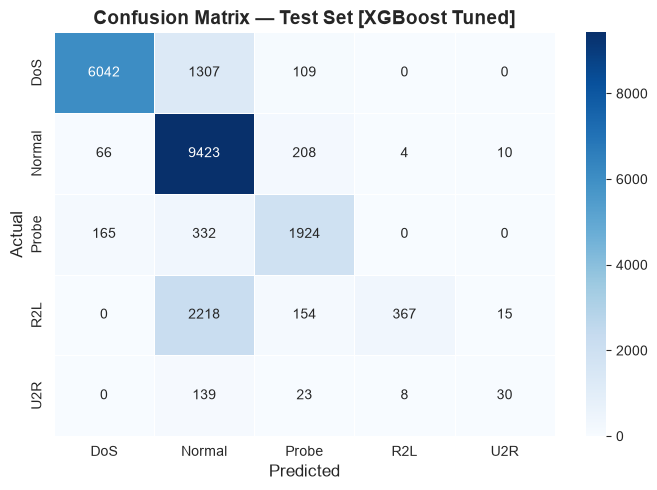

Saved → /Users/adityasitapara/Desktop/NIDS/models/confusion_matrix.png


In [24]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual',    fontsize=12)
ax.set_title(f'Confusion Matrix — Test Set [{best_name}]', fontsize=14, fontweight='bold')
plt.tight_layout()

cm_path = os.path.join(MODELS_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150)
plt.show()
print(f'Saved → {cm_path}')

## 5. Feature Importance

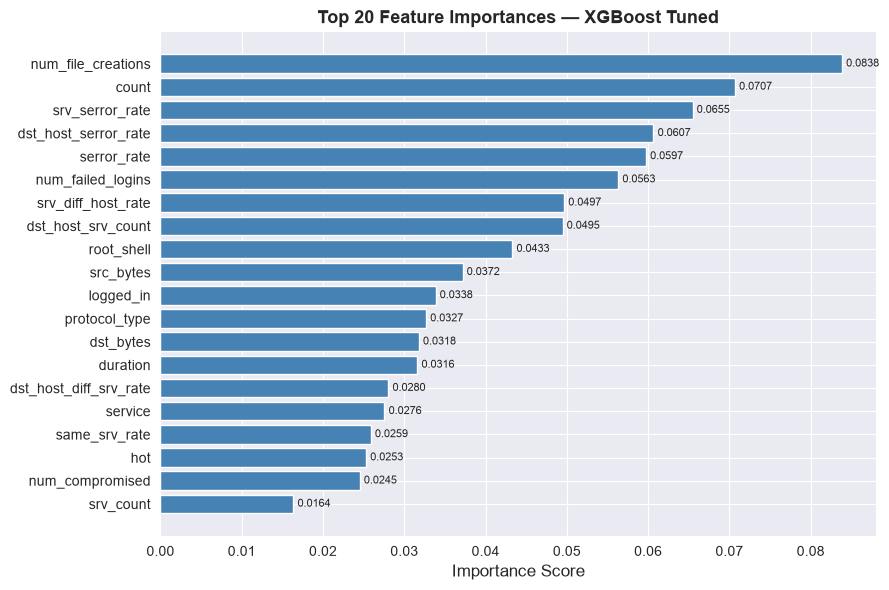

Saved → /Users/adityasitapara/Desktop/NIDS/models/feature_importance.png


In [25]:
importances = (
    model.feature_importances_
    if hasattr(model, 'feature_importances_') else
    np.zeros(len(feature_names))
)
top_n    = 20
top_idx  = np.argsort(importances)[::-1][:top_n]
top_names = [feature_names[i] for i in top_idx]
top_vals  = importances[top_idx]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_names[::-1], top_vals[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title(f'Top {top_n} Feature Importances — {best_name}', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
plt.tight_layout()

fi_path = os.path.join(MODELS_DIR, 'feature_importance.png')
plt.savefig(fi_path, dpi=150)
plt.show()
print(f'Saved → {fi_path}')

## 6. SHAP Explainability

> SHAP values are computed only for tree-based models. Skipped if the best model is not tree-based.

In [26]:
rng      = np.random.default_rng(42)
bg_idx   = rng.choice(len(X_train), size=500, replace=False)
X_bg     = X_train[bg_idx]
shap_idx = rng.choice(len(X_test), size=min(1000, len(X_test)), replace=False)
X_shap   = X_test[shap_idx]

print('Computing SHAP values...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
print('SHAP values shape:', np.array(shap_values).shape)

Computing SHAP values...
SHAP values shape: (1000, 40, 5)


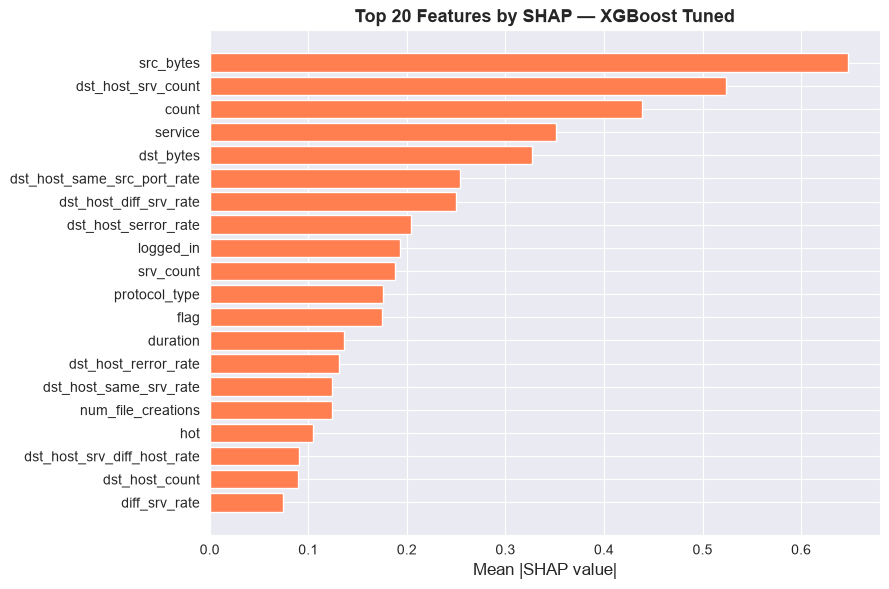

Saved → /Users/adityasitapara/Desktop/NIDS/models/shap_importance.png


In [27]:
sv_3d         = np.array(shap_values)
shap_abs_mean = np.abs(sv_3d).mean(axis=(0, 2)) if sv_3d.ndim == 3 else np.abs(sv_3d).mean(axis=0)

shap_top_idx   = np.argsort(shap_abs_mean)[::-1][:top_n]
shap_top_names = [feature_names[i] for i in shap_top_idx]
shap_top_vals  = shap_abs_mean[shap_top_idx]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(shap_top_names[::-1], shap_top_vals[::-1], color='coral', edgecolor='white')
ax.set_xlabel('Mean |SHAP value|', fontsize=12)
ax.set_title(f'Top {top_n} Features by SHAP — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()

shap_path = os.path.join(MODELS_DIR, 'shap_importance.png')
plt.savefig(shap_path, dpi=150)
plt.show()
print(f'Saved → {shap_path}')

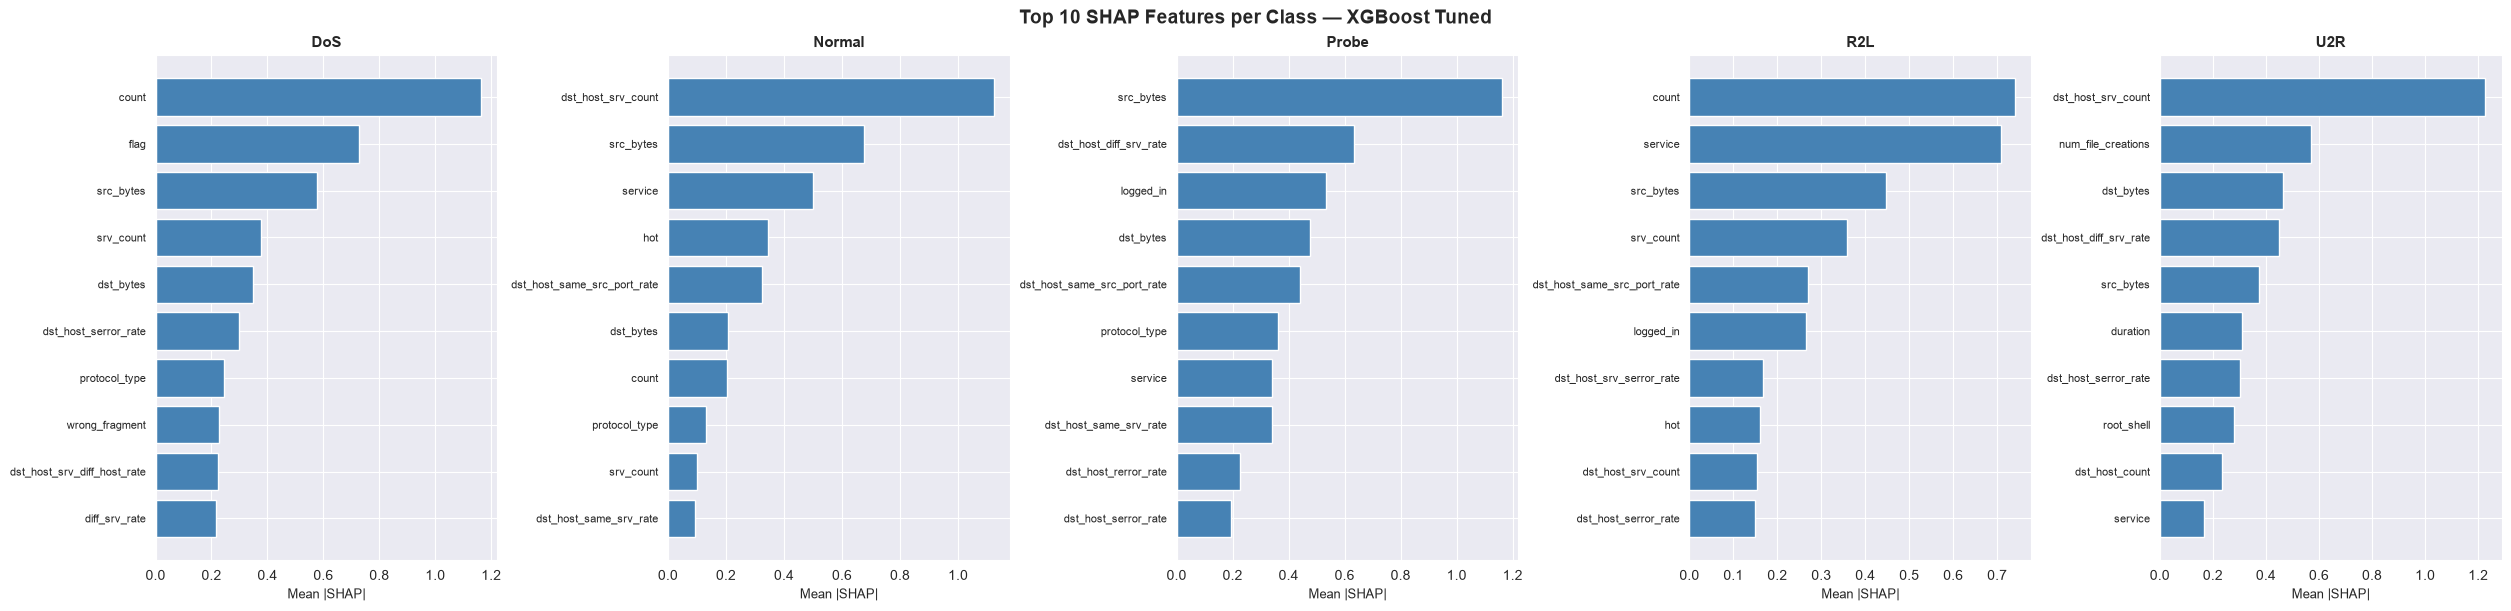

Saved → /Users/adityasitapara/Desktop/NIDS/models/shap_per_class.png


In [28]:
shap_class_path = os.path.join(MODELS_DIR, 'shap_per_class.png')
sv_arr = np.array(shap_values)   # (n_samples, n_features, n_classes) or (n_samples, n_features)

if sv_arr.ndim == 3:
    n_classes = sv_arr.shape[2]
    fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 6), constrained_layout=True)
    if n_classes == 1:
        axes = [axes]
    for i, (cls, ax) in enumerate(zip(CLASS_NAMES, axes)):
        sv_cls   = sv_arr[:, :, i]
        mean_abs = np.abs(sv_cls).mean(axis=0)
        top_i    = np.argsort(mean_abs)[-10:]
        ax.barh([feature_names[j] for j in top_i], mean_abs[top_i], color='steelblue', edgecolor='white')
        ax.set_title(cls, fontweight='bold', fontsize=11)
        ax.set_xlabel('Mean |SHAP|', fontsize=9)
        ax.tick_params(axis='y', labelsize=8)
    fig.suptitle(f'Top 10 SHAP Features per Class — {best_name}', fontsize=14, fontweight='bold')
    plt.savefig(shap_class_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved → {shap_class_path}')
else:
    shap_class_path = None
    print('Per-class SHAP skipped (2D shap_values — binary or RF leaf output)')

## 7. Save Model + Model Info JSON

In [29]:
# ── 7a. Save model ─────────────────────────────────────────────
model_path = os.path.join(MODELS_DIR, 'model.pkl')
joblib.dump(model, model_path)
print(f'✓ Model saved   → {model_path}')

# ── 7b. Confusion matrix dict ──────────────────────────────────
cm_dict = {
    actual_cls: {pred_cls: int(cm[i][j]) for j, pred_cls in enumerate(CLASS_NAMES)}
    for i, actual_cls in enumerate(CLASS_NAMES)
}

# ── 7c. Feature importance list ────────────────────────────────
feature_importance_list = [
    [feature_names[i], float(importances[i])]
    for i in np.argsort(importances)[::-1][:20]
]

# ── 7d. Comparison table for model_info ───────────────────────
comparison = results.reset_index().rename(columns={'Model': 'model'}).to_dict(orient='records')

# ── 7e. Assemble model_info.json ───────────────────────────────
model_info = {
    'algorithm'          : best_name,
    'model_type'         : model_type,
    'dataset'            : 'NSL-KDD',
    'samples'            : int(len(X_train)),
    'features'           : int(len(feature_names)),
    'train_size'         : f'{len(X_train):,} rows (after SMOTE)',
    'test_accuracy'      : round(test_acc, 4),
    'test_f1_weighted'   : round(test_f1, 4),
    'val_accuracy'       : round(val_acc, 4),
    'val_f1_weighted'    : round(val_f1, 4),
    'confusion_matrix'   : cm_dict,
    'feature_importance' : feature_importance_list,
    'classes'            : CLASS_NAMES,
    'mlflow_run_id'      : RUN_ID,
    'hyperparameters'    : {k: str(v) for k, v in params.items()},
    'model_comparison'   : comparison,
}

info_path = os.path.join(MODELS_DIR, 'model_info.json')
with open(info_path, 'w') as f:
    json.dump(model_info, f, indent=2)
print(f'✓ Model info saved → {info_path}')

✓ Model saved   → /Users/adityasitapara/Desktop/NIDS/models/model.pkl
✓ Model info saved → /Users/adityasitapara/Desktop/NIDS/models/model_info.json


## 8. Log to MLflow (artifacts)

In [30]:
# ── Set experiment context to match the winning run ───────────
exp_name_map = {
    'XGBoost Baseline': 'NIDS-XGBoost',
    'XGBoost Tuned':    'NIDS-XGBoost',
    'Random Forest':    'NIDS-RandomForest',
}
mlflow.set_experiment(exp_name_map[best_name])

with mlflow.start_run(run_id=RUN_ID):
    if model_type == 'xgboost':
        mlflow.xgboost.log_model(model, name='model')
    else:
        mlflow.sklearn.log_model(model, name='model')
    mlflow.log_artifact(cm_path,         'plots')
    mlflow.log_artifact(fi_path,         'plots')
    mlflow.log_artifact(shap_path,       'plots')
    if shap_class_path:
        mlflow.log_artifact(shap_class_path, 'plots')
    mlflow.log_artifact(info_path,       'model_info')

print('✓ All artifacts logged to MLflow')

✓ All artifacts logged to MLflow


## 9. Final Summary

In [31]:
print('=' * 60)
print('  NIDS — Model Training Complete')
print('=' * 60)
print(f'  Winner         : {best_name}')
print(f'  Dataset        : NSL-KDD')
print(f'  Features       : {len(feature_names)}')
print(f'  Train rows     : {len(X_train):,} (post-SMOTE)')
print(f'  Classes        : {CLASS_NAMES}')
print()
print('  Model Comparison:')
print(results.round(4).to_string())
print()
print(f'  Val  Accuracy : {val_acc:.4f}  |  Val  F1 : {val_f1:.4f}')
print(f'  Test Accuracy : {test_acc:.4f}  |  Test F1 : {test_f1:.4f}')
print()
print(f'  model.pkl       → {model_path}')
print(f'  model_info.json → {info_path}')
print('=' * 60)
print('  Backend is ready. Start FastAPI with:')
print('    cd backend && uvicorn main:app --reload')
print('=' * 60)

  NIDS — Model Training Complete
  Winner         : XGBoost Tuned
  Dataset        : NSL-KDD
  Features       : 40
  Train rows     : 269,370 (post-SMOTE)
  Classes        : ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']

  Model Comparison:
                  Val Acc  Test Acc  Test F1 (w)
Model                                           
XGBoost Baseline   0.9993    0.7837       0.7542
XGBoost Tuned      0.9975    0.7889       0.7582
Random Forest      0.9987    0.7503       0.7035

  Val  Accuracy : 0.9975  |  Val  F1 : 0.9976
  Test Accuracy : 0.7889  |  Test F1 : 0.7582

  model.pkl       → /Users/adityasitapara/Desktop/NIDS/models/model.pkl
  model_info.json → /Users/adityasitapara/Desktop/NIDS/models/model_info.json
  Backend is ready. Start FastAPI with:
    cd backend && uvicorn main:app --reload
